<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/Spam_ham_Prediction_Using_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Columns: Index(['Unnamed: 0', 'label', 'text', 'label_num'], dtype='object')
Missing values:
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64
Confusion Matrix:
[[1108   13]
 [   2  429]]


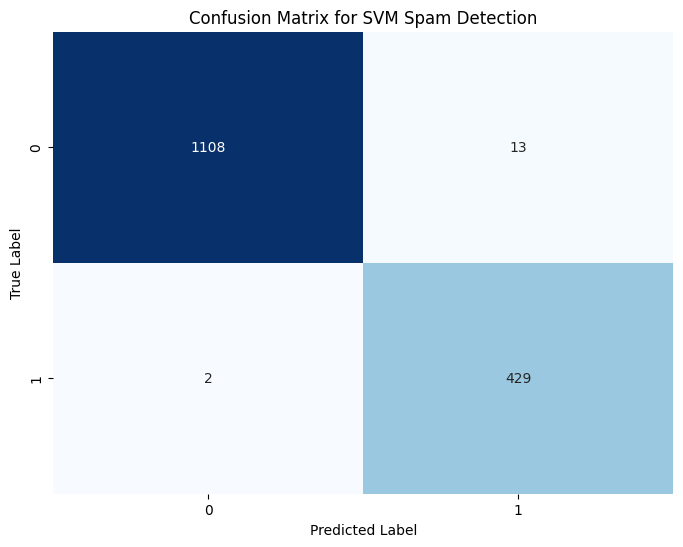

In [ ]:
# Step 1: Import required libraries
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 2: Load your dataset
data = pd.read_csv('spam_ham_dataset.csv')

print("Dataset Preview:")
print(data.head())

# Step 3: Check column names
print("Columns:", data.columns)

# Step 4: Handle missing values
print("Missing values:")
print(data.isnull().sum())
data.dropna(inplace=True)

# ---- Adjust column names based on your dataset ----
# Common cases:
# If columns are 'label' and 'text'
# OR 'Category' and 'Message'

# Update here if needed:
X_text = data['text']      # change if your column name is different
y = data['label']          # change if needed

# Step 5: Convert labels (ham=0, spam=1)
y = y.map({'ham': 0, 'spam': 1})

# Step 6: Text preprocessing using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X_text)

# Step 7: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Step 8: Train SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

# Step 9: Predictions
y_pred = svm_model.predict(X_test)

# Step 10: Evaluation
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for SVM Spam Detection")

plt.show()


In [ ]:
print("accuracy",accuracy*100)

accuracy 99.03350515463917
